In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Image, Markdown, display

import shutil
from data.share_data import load_share_data
from scripts.madrl import SCHEMES, compute_ev_agent_cost_summary, compute_ev_cost_summary, plot_madrl_outputs, run_madrl_scheme_experiment
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/madrl_traindays_7")
base_scheme_name = "madrl_base"
scheme_name = "madrl_base_EV_soft_progress_continuous"
controller_name = "MADRL_BASE_PROGRESS_CONTINUOUS"

cfg, run_dir = load_experiment_context(run_dir)
# EV soft-constraint + progress penalty configuration
cfg.env.ev_enabled = True
cfg.env.ev_state_continuity = True
cfg.model.action_dim = 3
cfg.env.ev_departure_constraint_mode = "soft"
cfg.env.ev_arrival_soc = 0.30
cfg.env.ev_hard_projection_enabled = False
cfg.env.ev_emergency_charging_enabled = False
cfg.env.ev_capacity_kwh = (60.0, 60.0, 60.0)
cfg.env.ev_soc_min = 0.10
cfg.env.ev_soc_max = 0.95
cfg.env.ev_departure_soc_req = 0.90
cfg.env.ev_max_charge_kw = (11.0, 11.0, 11.0)
cfg.env.ev_efficiency = 0.95
cfg.env.ev_arrival_step = 72
cfg.env.ev_departure_step = 28
cfg.reward.ev_departure_penalty_weight = 1000.0
cfg.reward.ev_progress_penalty_weight = 50.0
cfg.reward.ev_soc_regularization_weight = 0.005
cfg.reward.throughput_bonus_eur_per_kwh_max = 0.001
# Debug runs use a fixed two-day training window.
cfg.env.train_window_days = 7
# train numbers
cfg.train.num_envs = 4
cfg.train.buffer_size = 100_000
cfg.train.batch_size = 512
cfg.train.learning_starts = 5376
cfg.train.actor_learning_starts = 8_064
cfg.train.n_step_return = 96
cfg.train.noise_decay_steps = 100_000
cfg.train.feasible_random_exploration_decay_steps = 50_000

variant_config_path = run_dir / "tables" / f"config_{scheme_name}.json"
variant_config_path.parent.mkdir(parents=True, exist_ok=True)
variant_config_path.write_text(json.dumps(asdict(cfg), ensure_ascii=False, indent=2, default=str), encoding="utf-8")

share_data = load_share_data(run_dir / "share_data", cfg)
assert int(share_data.manifest["sequence_length"]) == int(cfg.obs.sequence_length)
spec = dict(next(item for item in SCHEMES if item["scheme"] == base_scheme_name))
spec["scheme"] = scheme_name
spec["controller"] = controller_name
spec["label"] = "MADRL + EV Soft Constraint + ProgressPenalty"
train_episodes = 1000
w_voltage, w_line, w_trafo = spec["reward"]

display(Markdown("# MADRL + EV Soft Constraint + Progress Penalty"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "scheme": scheme_name,
    "base_scheme": base_scheme_name,
    "controller": spec["controller"],
    "train_episodes": train_episodes,
    "device": cfg.runtime.device,
    "train_window_days": int(cfg.env.train_window_days),
    "train_episode_steps": int(cfg.env.episode_steps) * int(cfg.env.train_window_days),
    "action_dim": int(cfg.model.action_dim),
    "max_charge_rate": float(cfg.env.max_charge_rate),
    "init_soc": float(cfg.env.init_soc),
    "train_init_soc_low": float(cfg.env.train_init_soc_low),
    "train_init_soc_high": float(cfg.env.train_init_soc_high),
    "batch_size": int(cfg.train.batch_size),
    "gamma": float(cfg.algo.gamma),
    "tau": float(cfg.algo.tau),
    "hidden_dim": int(cfg.model.hidden_dim),
    "n_step_return": int(cfg.train.n_step_return),
    "ev_enabled": bool(cfg.env.ev_enabled),
    "ev_constraint_mode": cfg.env.ev_departure_constraint_mode,
    "ev_capacity_kwh": cfg.env.ev_capacity_kwh,
    "ev_arrival_soc": float(cfg.env.ev_arrival_soc),
    "ev_departure_soc_req": float(cfg.env.ev_departure_soc_req),
    "ev_max_charge_kw": cfg.env.ev_max_charge_kw,
    "ev_arrival_step": int(cfg.env.ev_arrival_step),
    "ev_departure_step": int(cfg.env.ev_departure_step),
    "ev_departure_penalty_weight": float(cfg.reward.ev_departure_penalty_weight),
    "ev_progress_penalty_weight": float(cfg.reward.ev_progress_penalty_weight),
    "throughput_bonus_eur_per_kwh_max": float(cfg.reward.throughput_bonus_eur_per_kwh_max),
    "w_voltage_pen": float(w_voltage),
    "w_line_pen": float(w_line),
    "w_trafo_pen": float(w_trafo),
}]))


# MADRL + EV Soft Constraint + Progress Penalty

,run_dir,scheme,base_scheme,controller,train_episodes,device,train_window_days,train_episode_steps,action_dim,max_charge_rate,...,ev_departure_soc_req,ev_max_charge_kw,ev_arrival_step,ev_departure_step,ev_departure_penalty_weight,ev_progress_penalty_weight,throughput_bonus_eur_per_kwh_max,w_voltage_pen,w_line_pen,w_trafo_pen
0,artifacts\runs\madrl_traindays_7,madrl_base_EV_soft_progress_continuous,madrl_base,MADRL_BASE_PROGRESS_CONTINUOUS,1000,cuda,7,672,3,0.5,...,0.9,"(11.0, 11.0, 11.0)",72,28,1000.0,50.0,0.001,0.0,0.0,0.0


In [3]:
result = run_madrl_scheme_experiment(cfg, run_dir, share_data, spec, episodes=train_episodes)

display(Markdown("## Train Summary"))
display(result["train_summary"])

saved = result["records"][scheme_name]
display(Markdown("## Test Metrics"))
display(saved["metrics_df"])
display(Markdown("## Agent Summary"))
display(saved["rollout"].summary)
pprint({"record_dir": str(saved["record_dir"])})

rollout = saved["rollout"]
display(Markdown("## Total Cost Summary - ProgressPenalty"))
cost_ts, cost_summary = compute_ev_cost_summary(rollout, cfg)
agent_cost_summary = compute_ev_agent_cost_summary(rollout, cfg)
display(cost_summary)
display(Markdown("PV cost currently set to zero unless curtailment price/penalty is configured. Progress penalty is a reward term, not operational cost."))
display(Markdown("### Cost by Agent"))
display(agent_cost_summary)
agent_ev = rollout.agent_df.copy()
if {"ev_soc", "ev_charge_kw"}.issubset(agent_ev.columns):
    dt_hours = float(getattr(cfg.env, "dt_hours", rollout.meta.get("dt_hours", 0.25)))
    required_soc = float(cfg.env.ev_departure_soc_req)
    departure_step = int(cfg.env.ev_departure_step)
    departure_rows = agent_ev.loc[agent_ev["step"].astype(int) == departure_step].copy()
    if departure_rows.empty and "ev_departure_gap" in agent_ev.columns:
        departure_rows = agent_ev.loc[agent_ev["ev_departure_gap"].astype(float) > 0.0].copy()
    if departure_rows.empty:
        departure_rows = agent_ev.sort_values(["episode_idx", "agent_id", "step"]).groupby(["episode_idx", "agent_id"], as_index=False).tail(1)
    if "ev_departure_gap" not in departure_rows.columns:
        departure_rows["ev_departure_gap"] = (required_soc - departure_rows["ev_soc"].astype(float)).clip(lower=0.0)
    energy = agent_ev.assign(ev_energy_kwh=agent_ev["ev_charge_kw"].astype(float).clip(lower=0.0) * dt_hours).groupby("agent_id", as_index=False)["ev_energy_kwh"].sum()
    cost_col = "ev_charging_cost_eur" if "ev_charging_cost_eur" in agent_ev.columns else None
    if cost_col:
        cost = agent_ev.groupby("agent_id", as_index=False)[cost_col].sum().rename(columns={cost_col: "ev_cost_eur"})
    else:
        cost = pd.DataFrame({"agent_id": sorted(agent_ev["agent_id"].unique()), "ev_cost_eur": 0.0})
    departure = departure_rows.groupby("agent_id", as_index=False).agg(departure_soc=("ev_soc", "min"), departure_gap=("ev_departure_gap", "max"))
    ev_summary = departure.merge(energy, on="agent_id", how="outer").merge(cost, on="agent_id", how="outer")
    if {"ev_progress_gap", "ev_progress_penalty"}.issubset(agent_ev.columns):
        progress = agent_ev.groupby("agent_id", as_index=False).agg(
            progress_penalty_total=("ev_progress_penalty", "sum"),
            progress_gap_mean=("ev_progress_gap", "mean"),
            progress_gap_max=("ev_progress_gap", "max"),
            progress_violation_steps=("ev_progress_gap", lambda values: int((values.astype(float) > 1e-9).sum())),
        )
        ev_summary = ev_summary.merge(progress, on="agent_id", how="outer")
    ev_summary = ev_summary.rename(columns={"agent_id": "agent"}).sort_values("agent")
    ev_summary["required_soc"] = required_soc
    ev_summary["satisfied"] = ev_summary["departure_gap"].fillna(0.0) <= 1e-6
    base_columns = ["agent", "departure_soc", "required_soc", "departure_gap", "satisfied", "ev_energy_kwh", "ev_cost_eur"]
    progress_columns = [column for column in ("progress_penalty_total", "progress_gap_mean", "progress_gap_max", "progress_violation_steps") if column in ev_summary.columns]
    ev_summary = ev_summary.loc[:, base_columns + progress_columns]
    display(Markdown("## EV Departure and Progress Summary"))
    display(ev_summary)
else:
    display(Markdown("## EV Departure and Progress Summary"))
    print("EV rollout fields are not available in this record. Re-run the EV soft progress experiment after updating scripts/madrl.py and utils/records.py.")


train madrl_base_EV_soft_progress_continuous:   0%|          | 0/1000 [00:00<?, ?episode/s]

MADRL + EV Soft Constraint + ProgressPenalty/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

## Train Summary

,scheme,controller,label,algo,projection,episodes,steps,updates,elapsed_s,vec_env_kind,...,action_sample_s,env_step_s,replay_add_s,sample_update_s,other_s,batch_size,num_envs,parallel_episode_sampling,model_path,record_dir
0,madrl_base_EV_soft_progress_continuous,MADRL_BASE_PROGRESS_CONTINUOUS,MADRL + EV Soft Constraint + ProgressPenalty,MATD3,False,1000,672000,166657,22891.290881,subproc,...,724.132774,14893.11637,230.814576,6957.372969,85.854192,512,4,unique_active,artifacts\runs\madrl_traindays_7\models\madrl\...,artifacts\runs\madrl_traindays_7\results\lstm\...


## Test Metrics

...

PV cost currently set to zero unless curtailment price/penalty is configured. Progress penalty is a reward term, not operational cost.

### Cost by Agent

,agent,battery_cost_eur,ev_cost_eur,pv_cost_eur,total_cost_eur,ev_charge_requested_kwh,ev_charge_executed_kwh,ev_charge_clipped_kwh,ev_overcharge_gap,ev_overcharge_penalty
0,0,-7.264607,100.916899,0.0,93.652292,1117.953169,645.052407,472.900762,0.0,0.0
1,1,-87.735032,105.747552,0.0,18.012521,1445.886707,645.772388,800.114318,0.0,0.0
2,2,-51.982926,129.012569,0.0,77.029643,1396.315160,656.842076,739.473083,0.0,0.0


## EV Departure and Progress Summary

,agent,departure_soc,required_soc,departure_gap,satisfied,ev_energy_kwh,ev_cost_eur,progress_penalty_total,progress_gap_mean,progress_gap_max,progress_violation_steps
0,0,0.95,0.9,0.0,True,645.052407,100.916899,23.410445,0.004842,0.234007,175
1,1,0.95,0.9,0.0,True,645.772388,105.747552,25.605302,0.002451,0.259409,41
2,2,0.95,0.9,0.0,True,656.842076,129.012569,41.919797,0.002833,0.240650,22


1. Power balance - EV soft constraint progress penalty


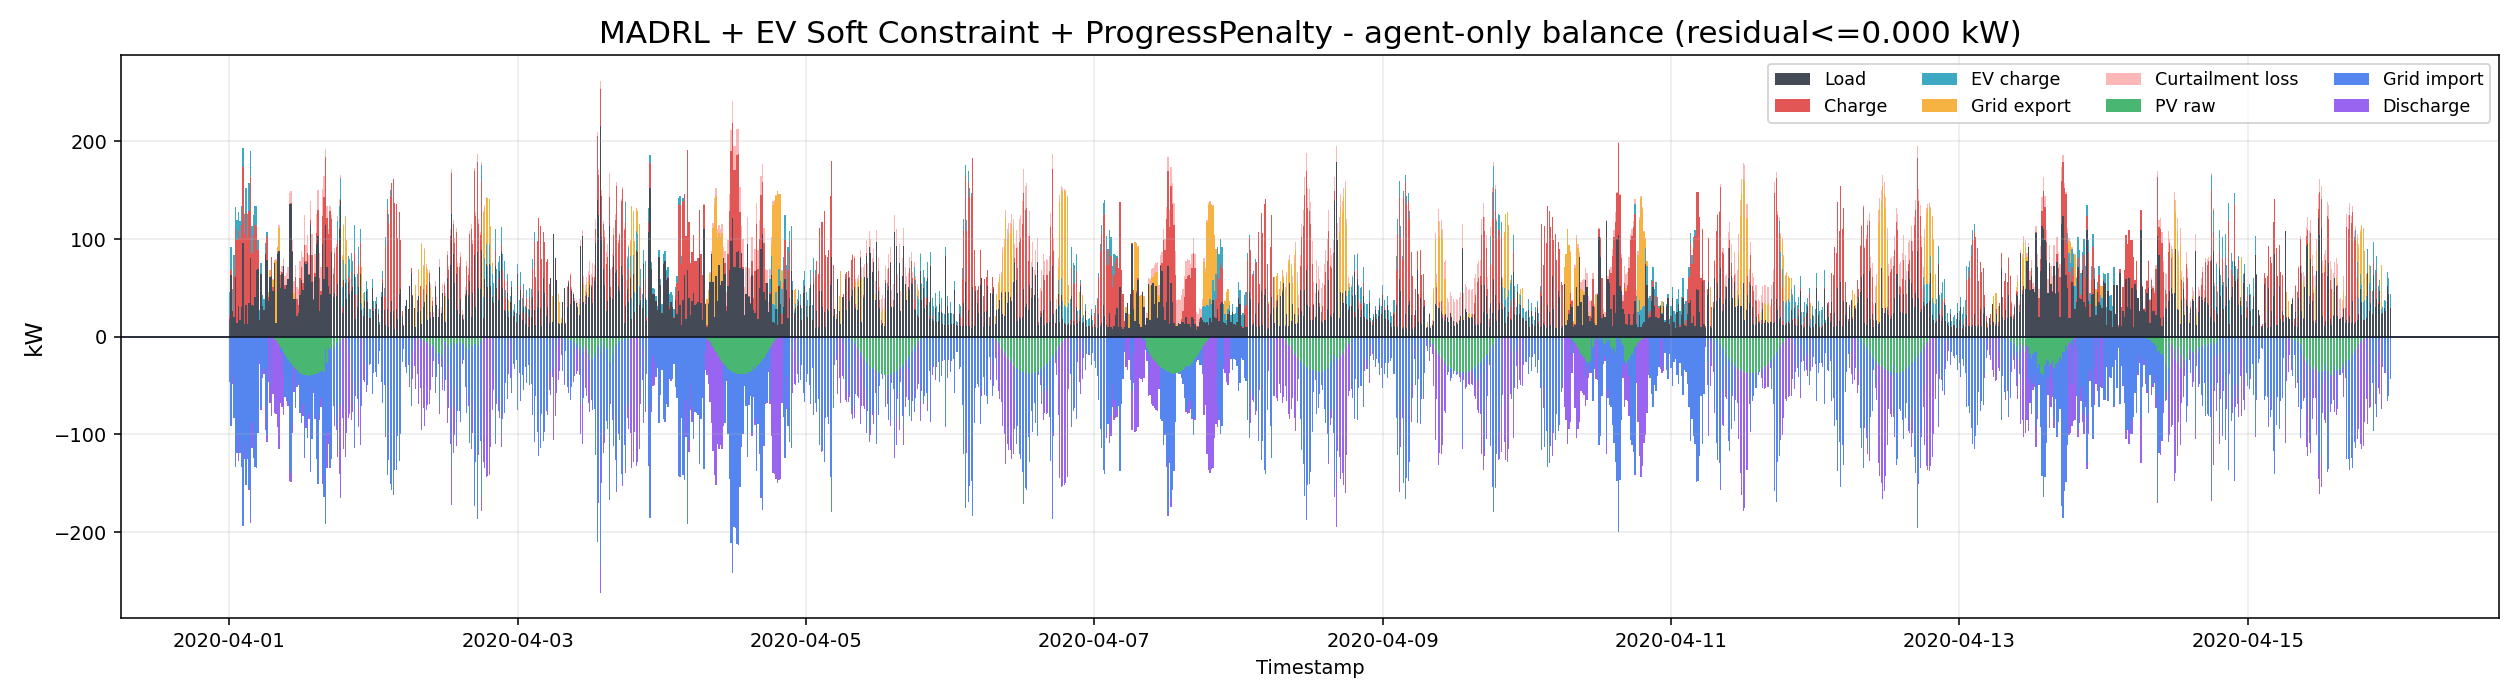

2. Price - EV soft constraint progress penalty


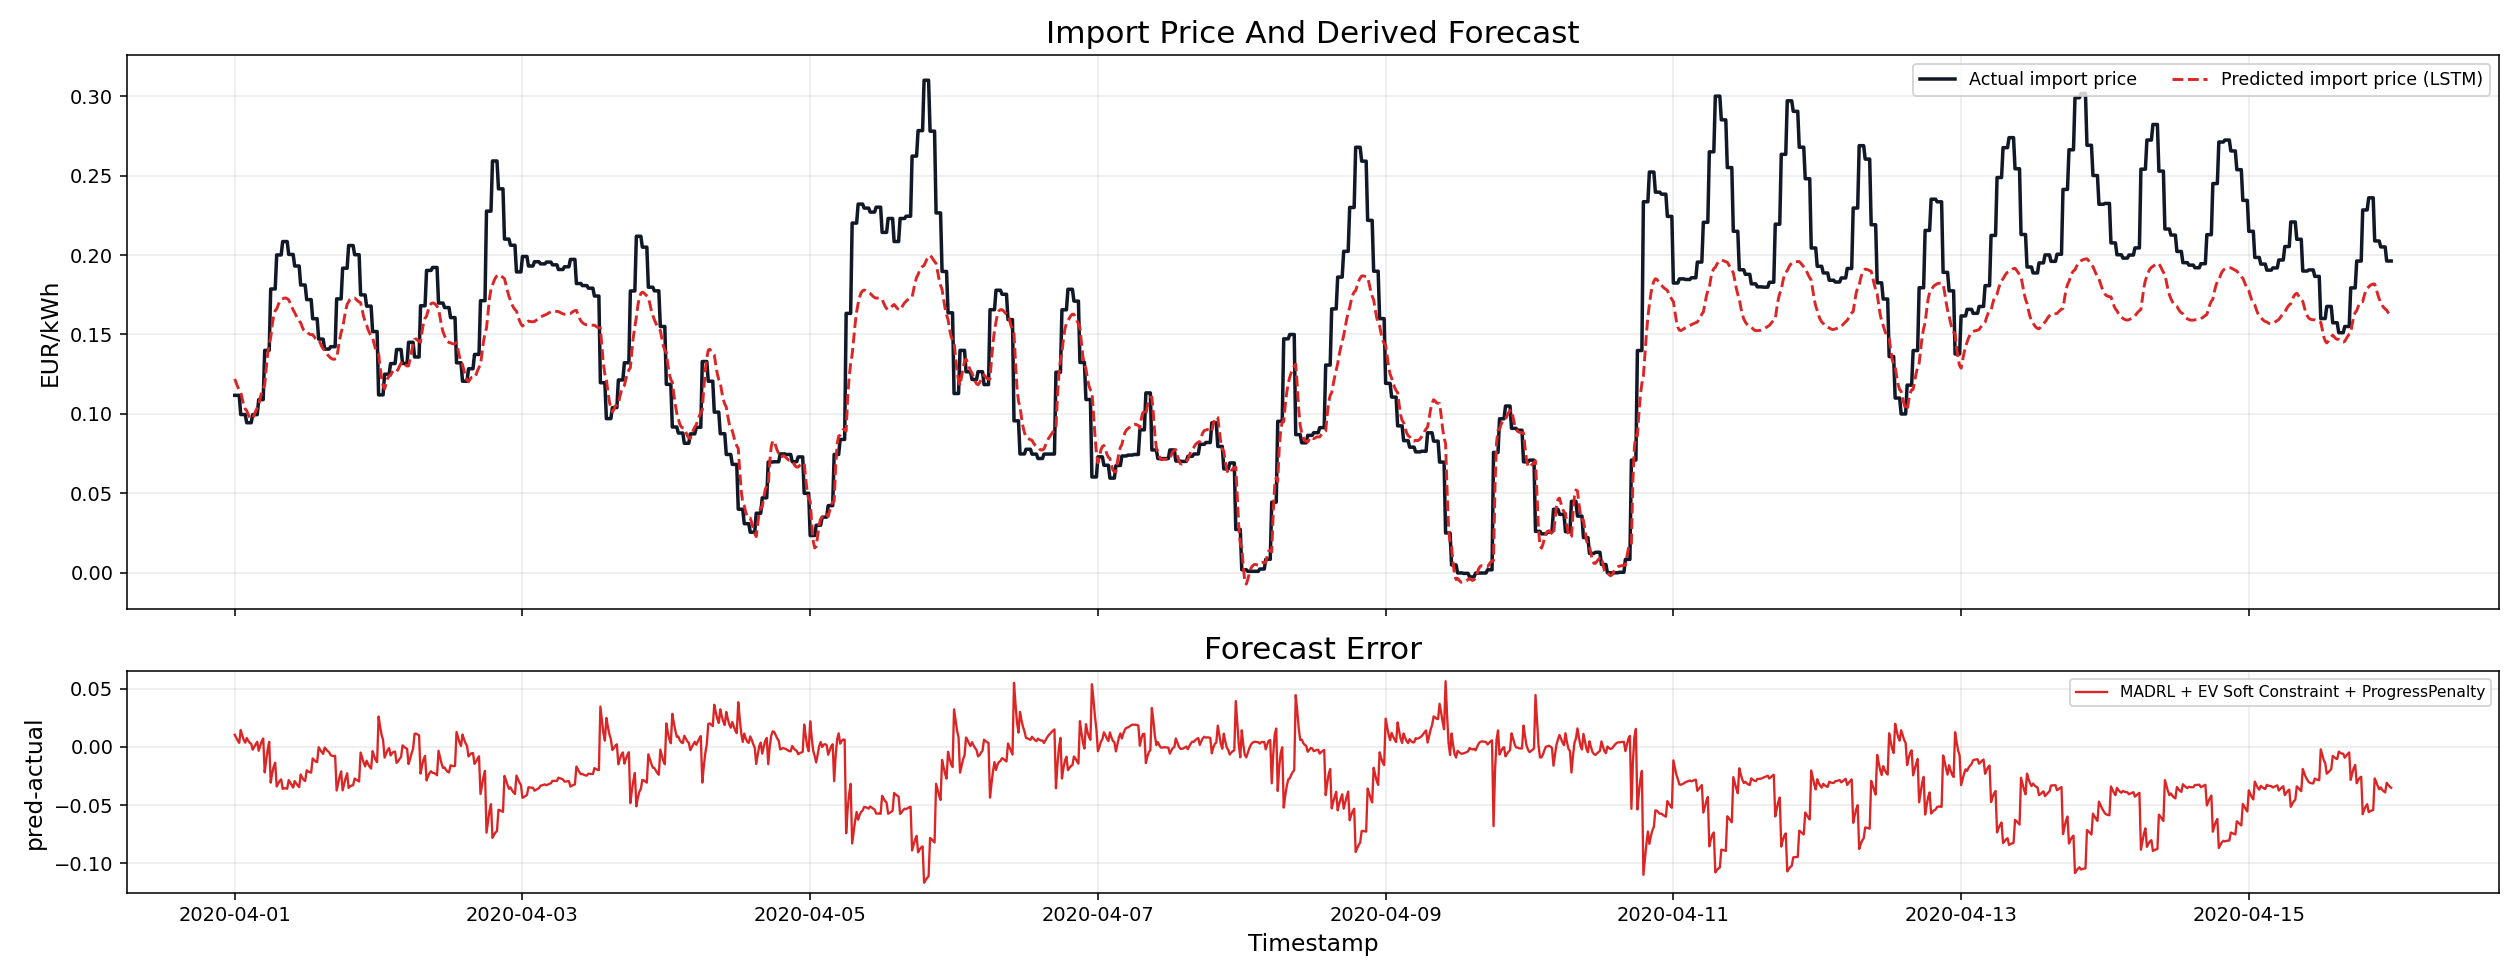

3. Battery power vs price - EV soft constraint progress penalty


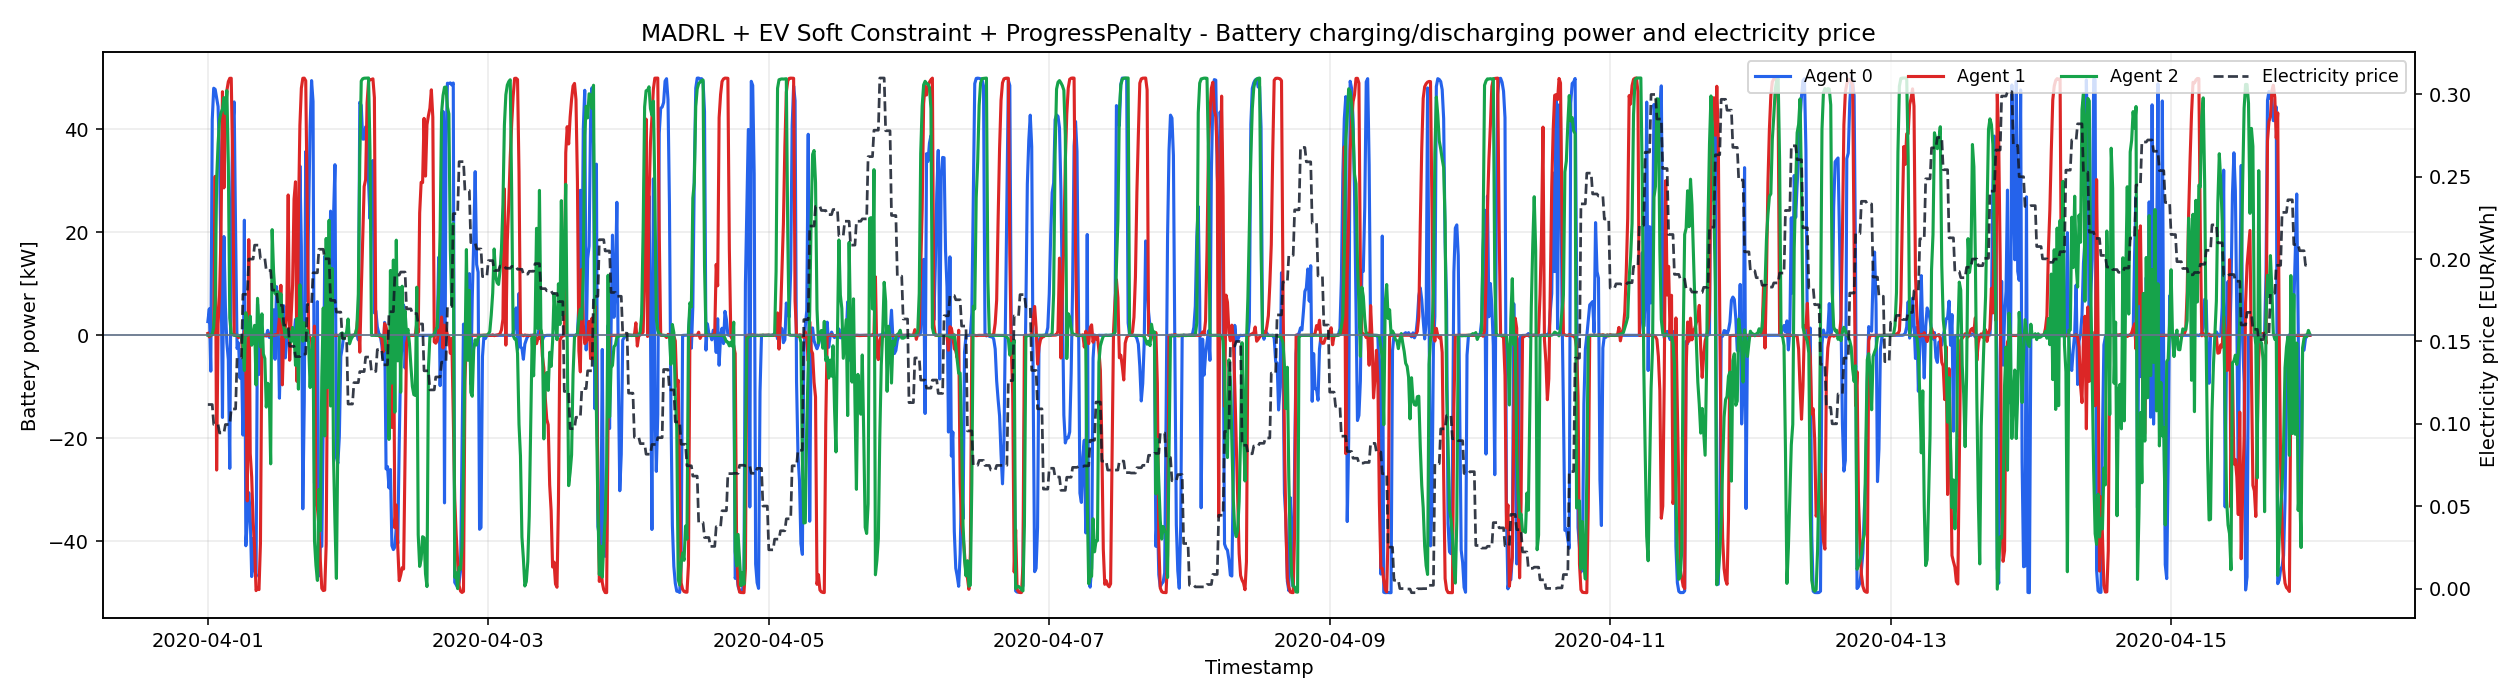

4. EV charging power vs price - EV soft constraint progress penalty


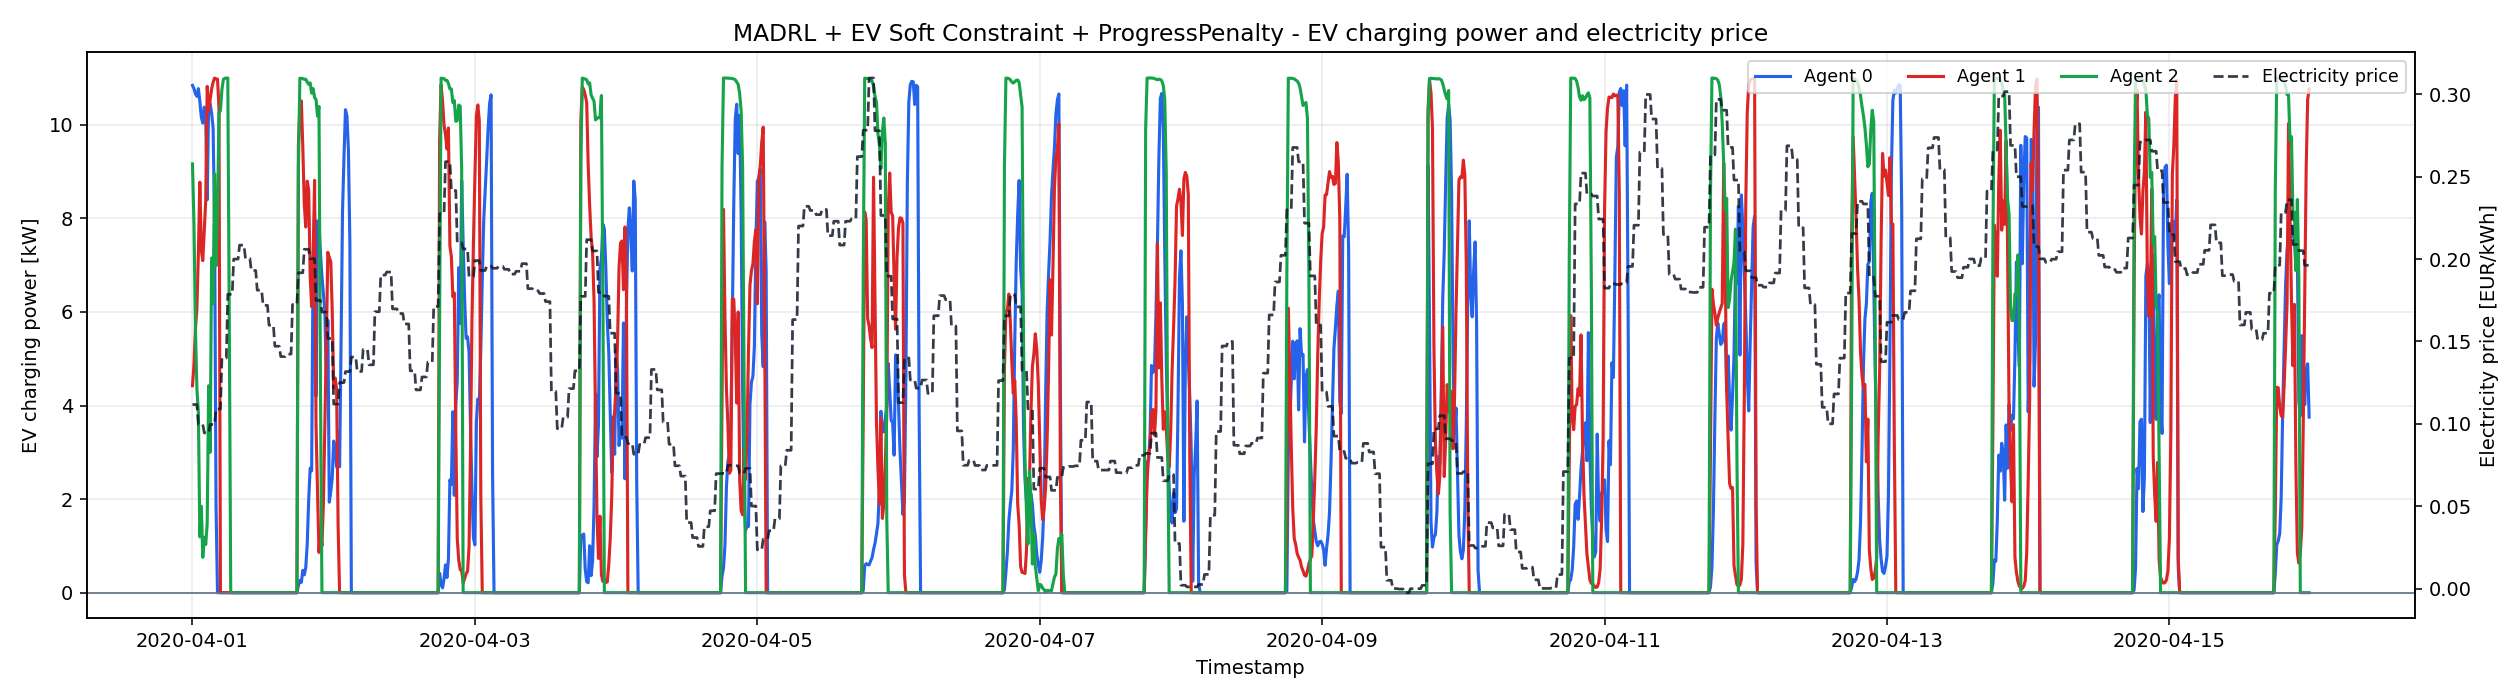

5. Total cumulative cost - EV soft constraint progress penalty


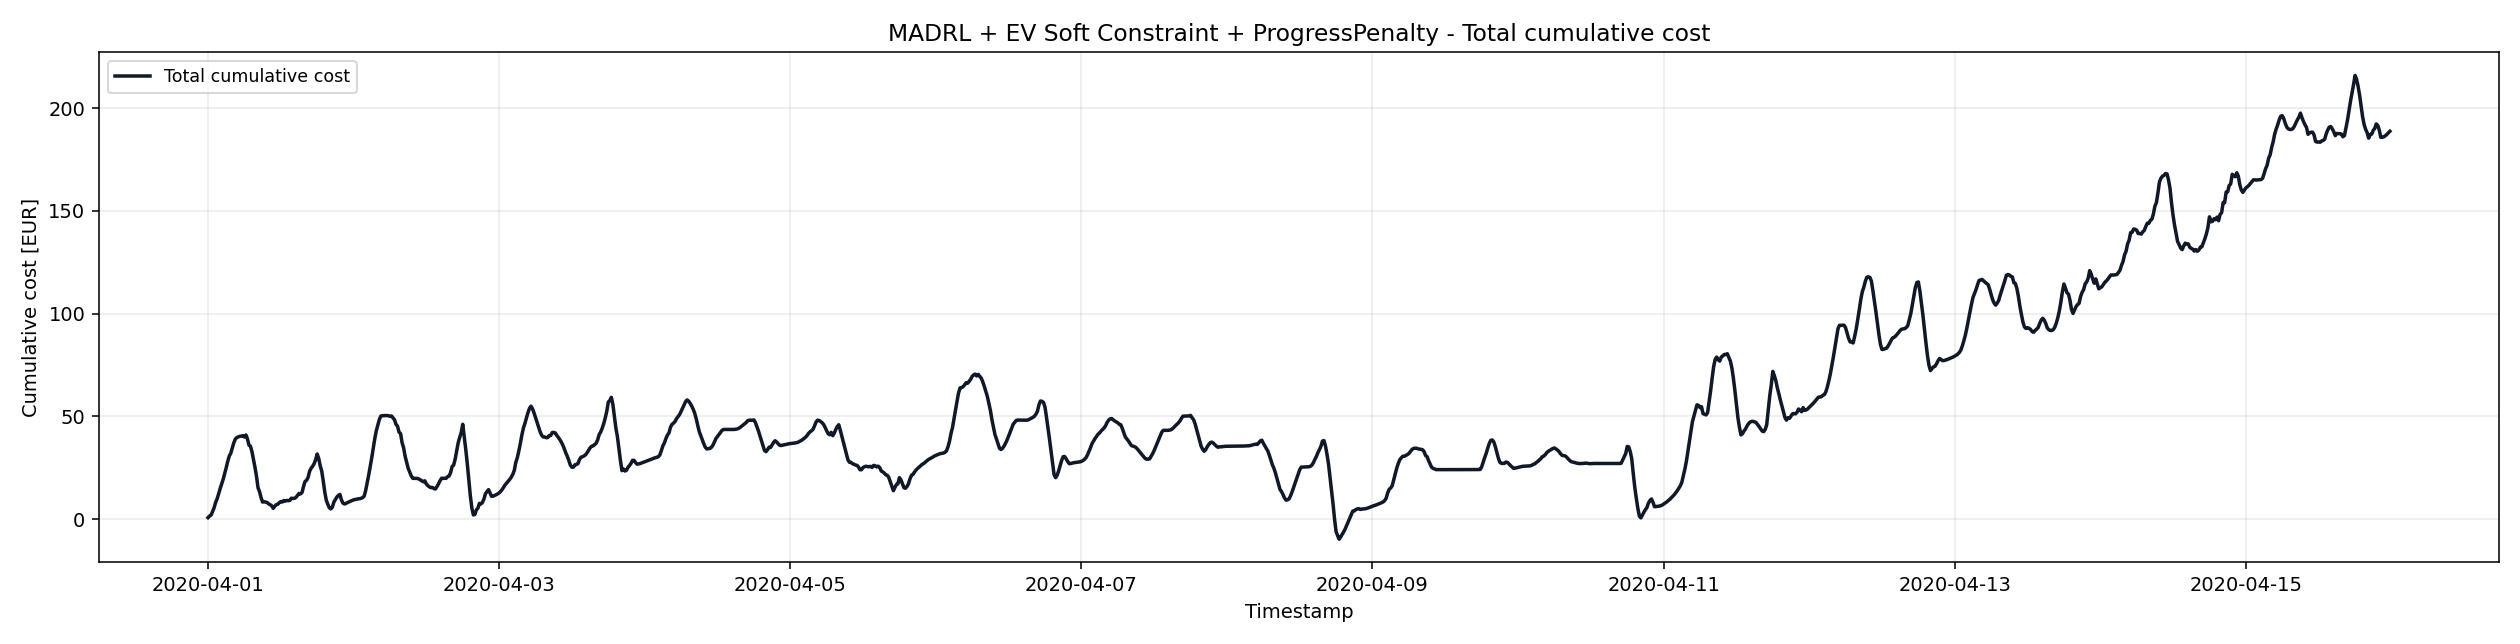

6. Cost components per step - EV soft constraint progress penalty


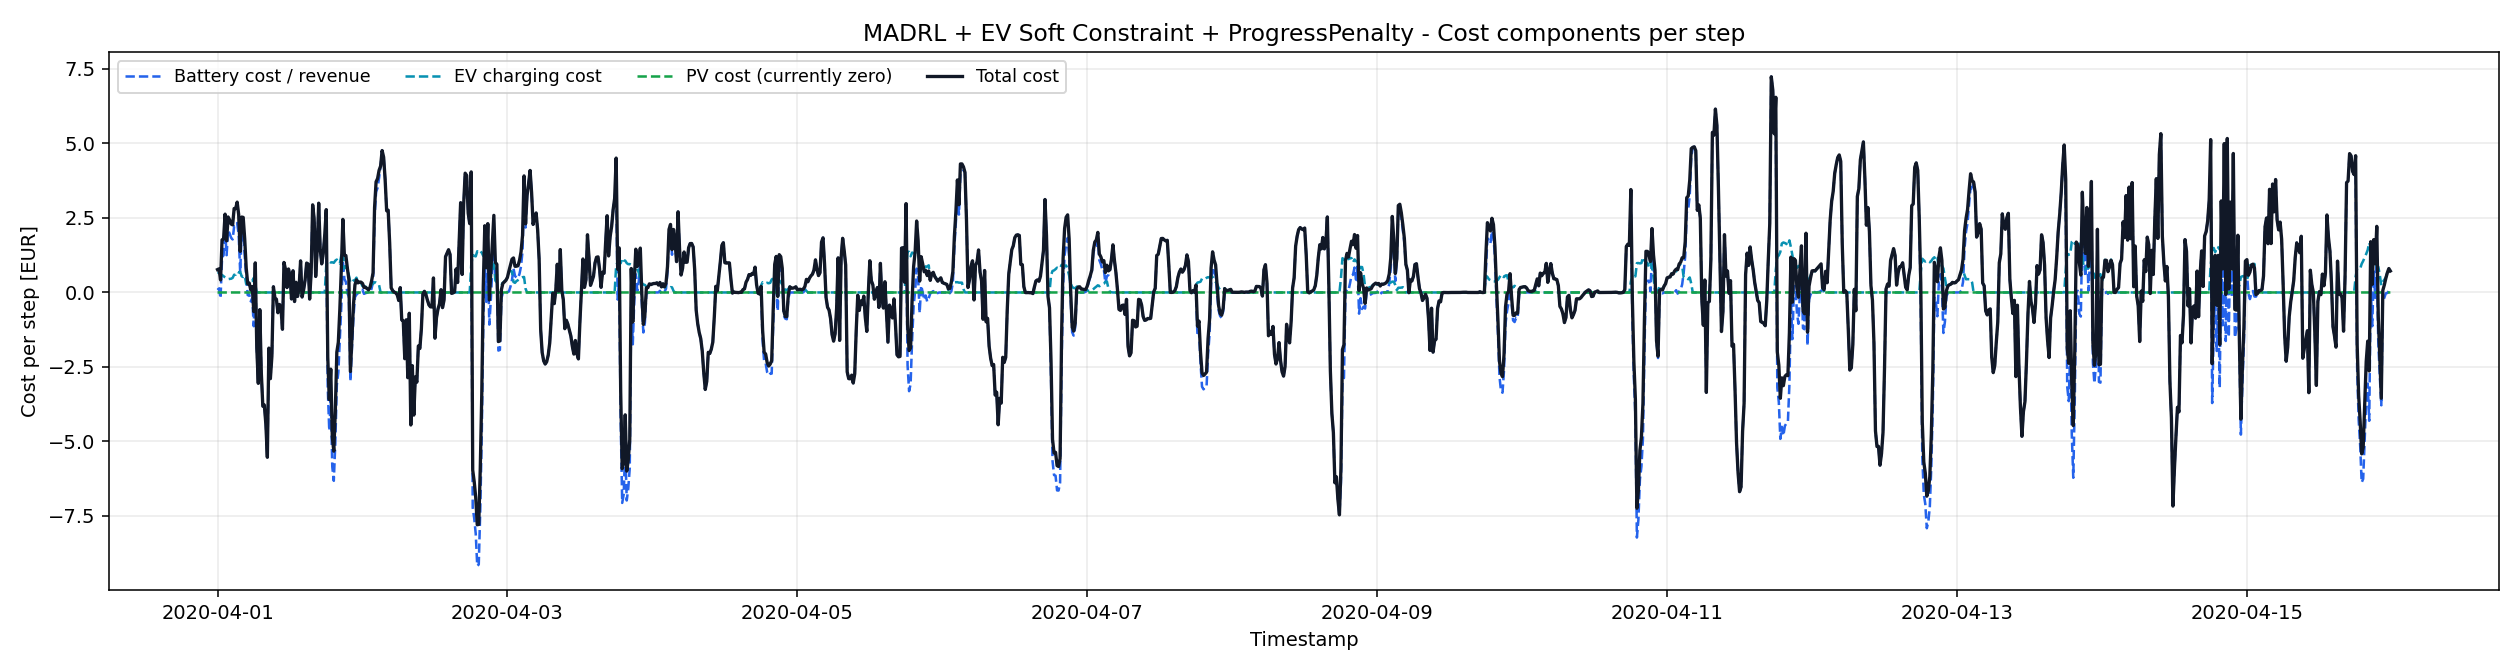

7. Cumulative cost components - EV soft constraint progress penalty


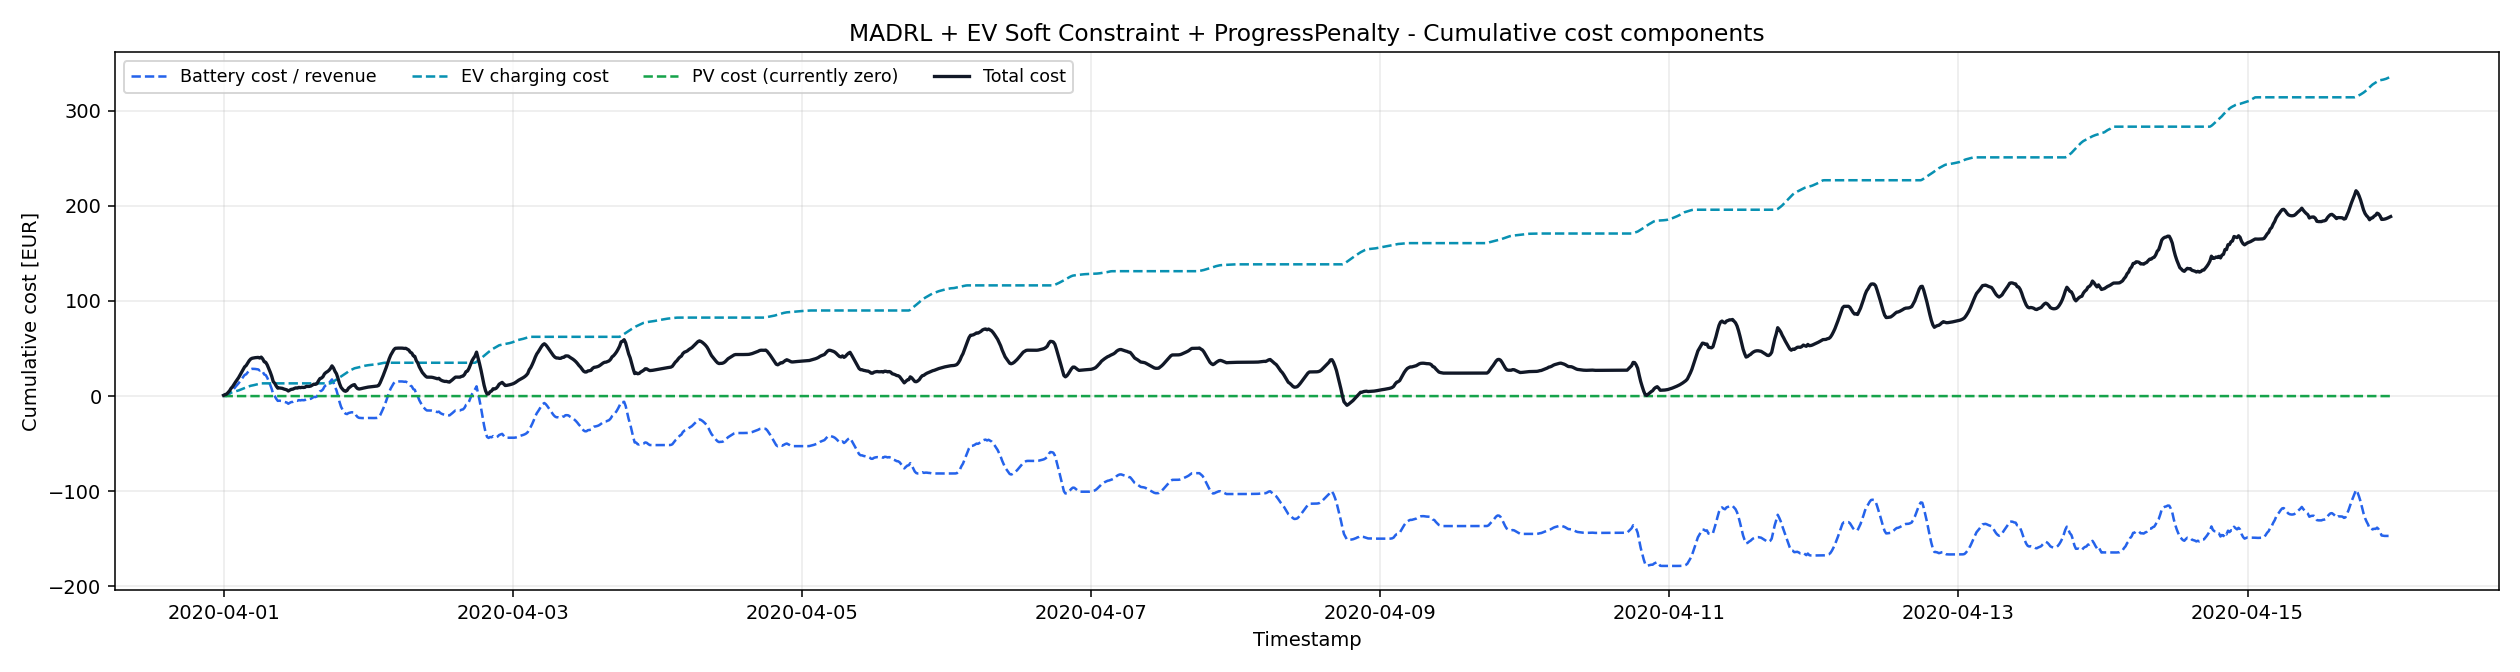

8. Battery power and SoC - EV soft constraint progress penalty


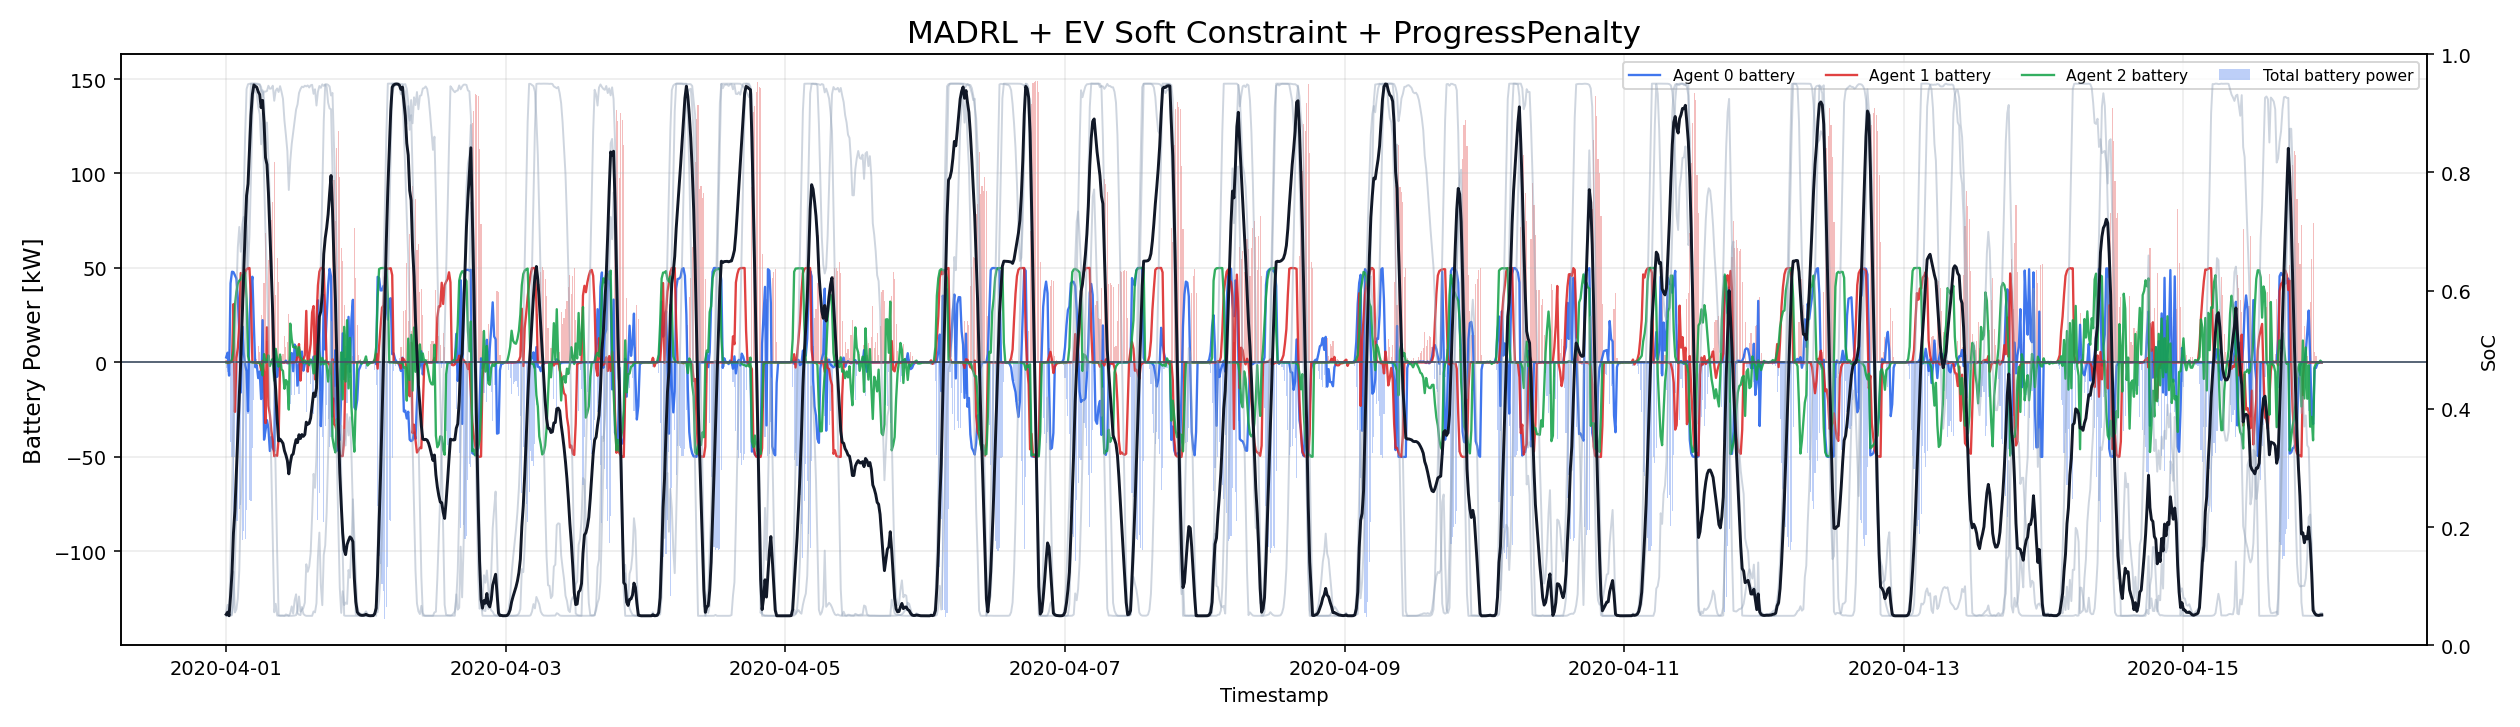

9. Voltage - EV soft constraint progress penalty


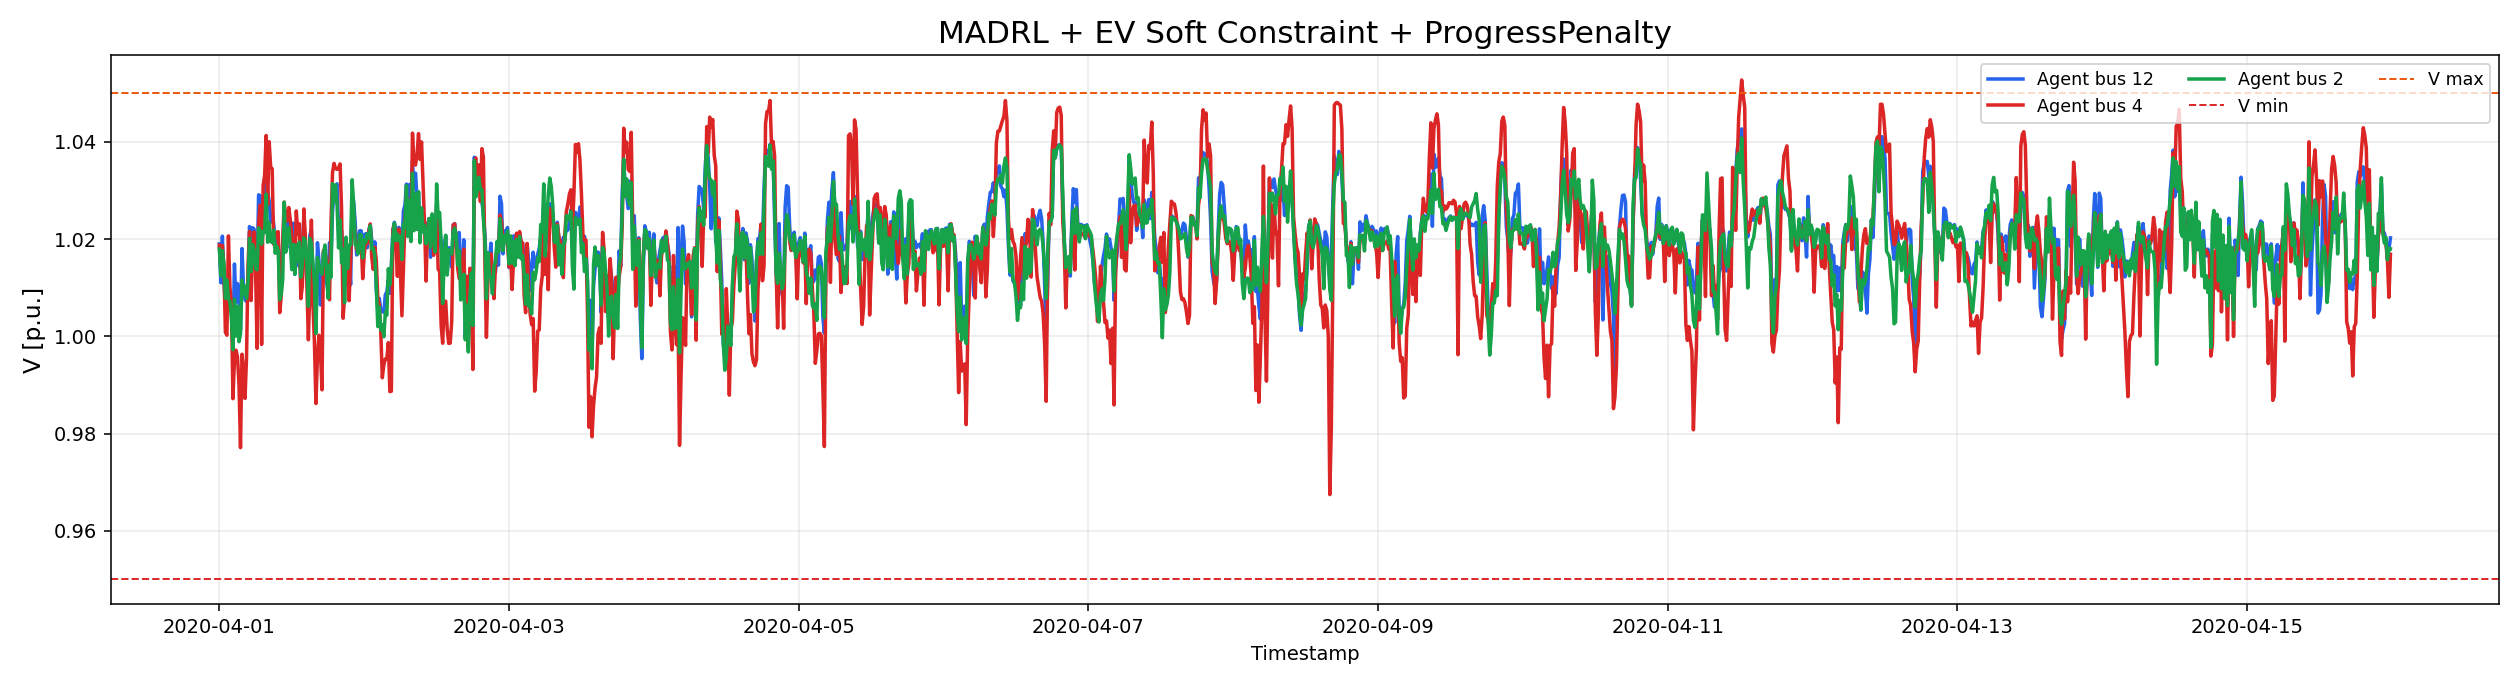

10. Net load - EV soft constraint progress penalty


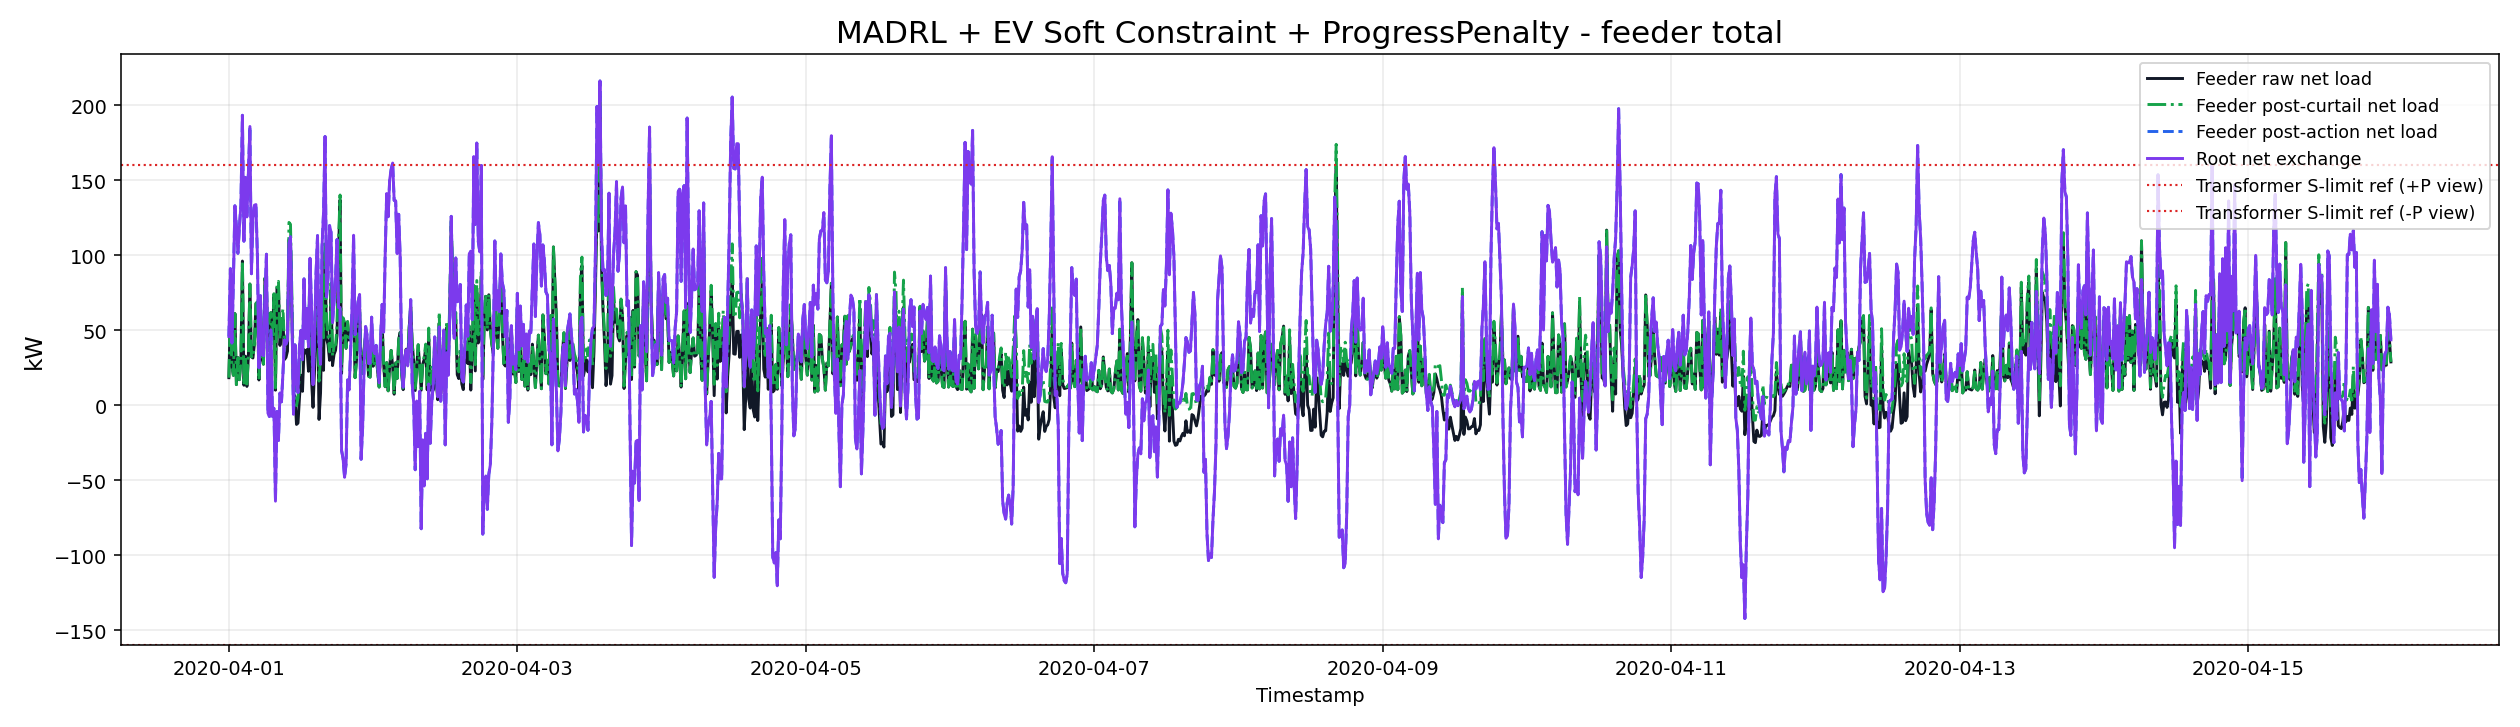

11. EV SOC - EV soft constraint progress penalty


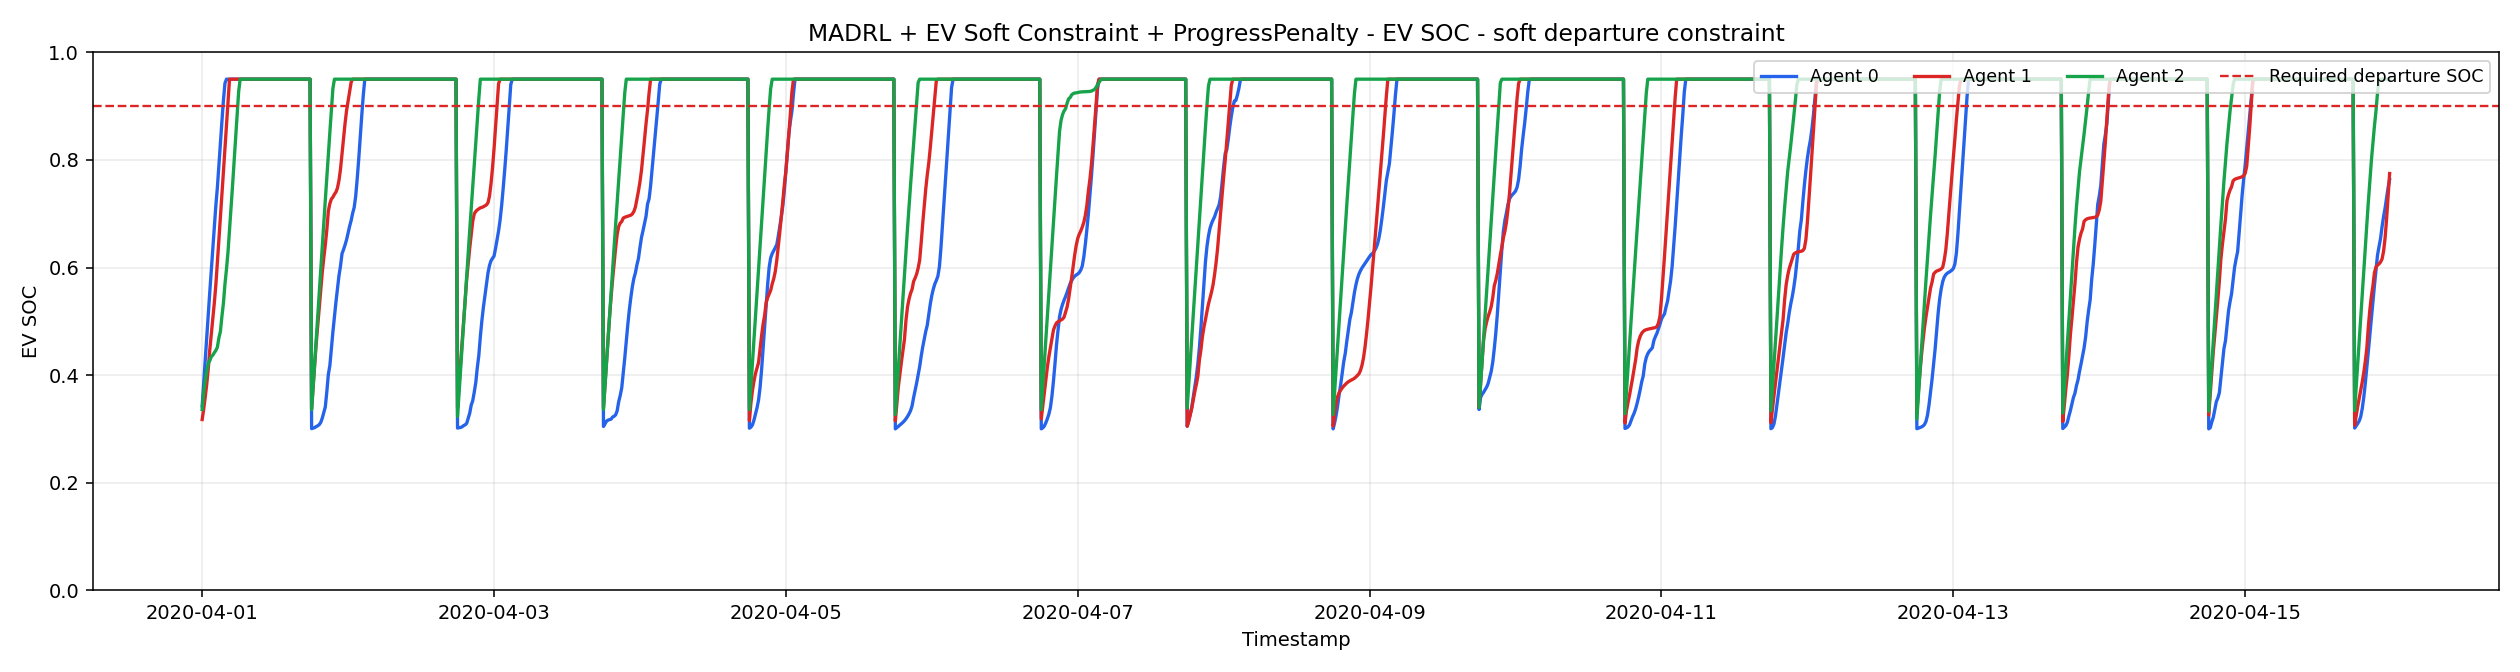

12. EV charging power - EV soft constraint progress penalty


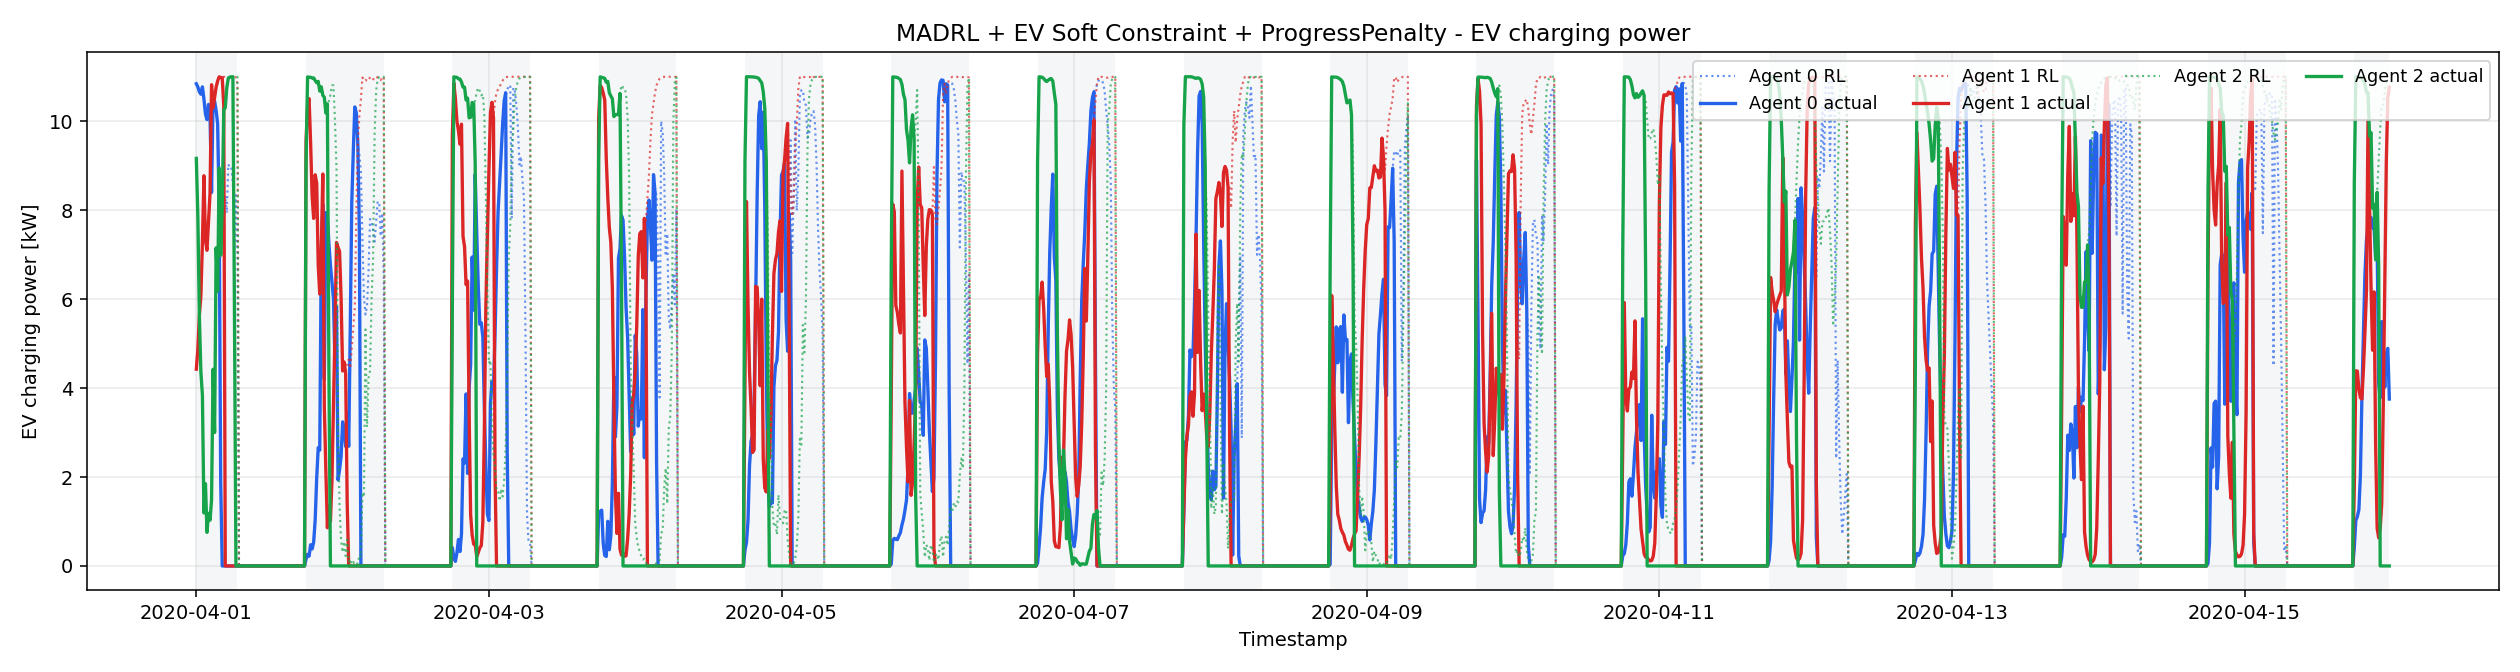

13. EV departure SOC requirement check - EV soft constraint progress penalty


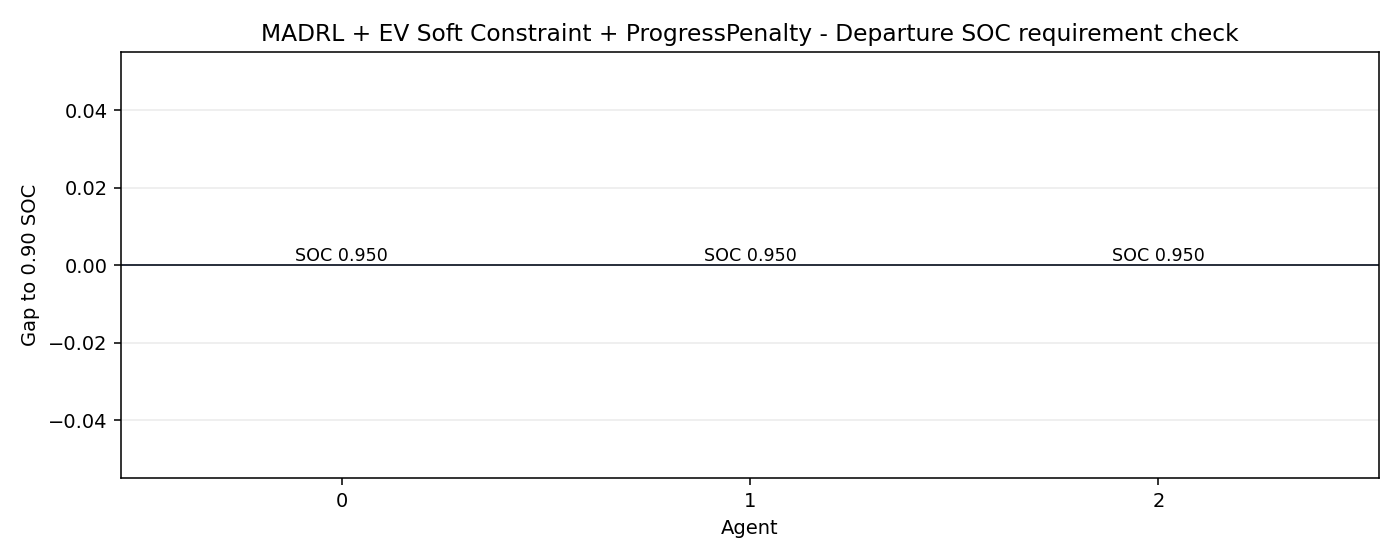

14. EV SOC progress target check - EV soft constraint progress penalty


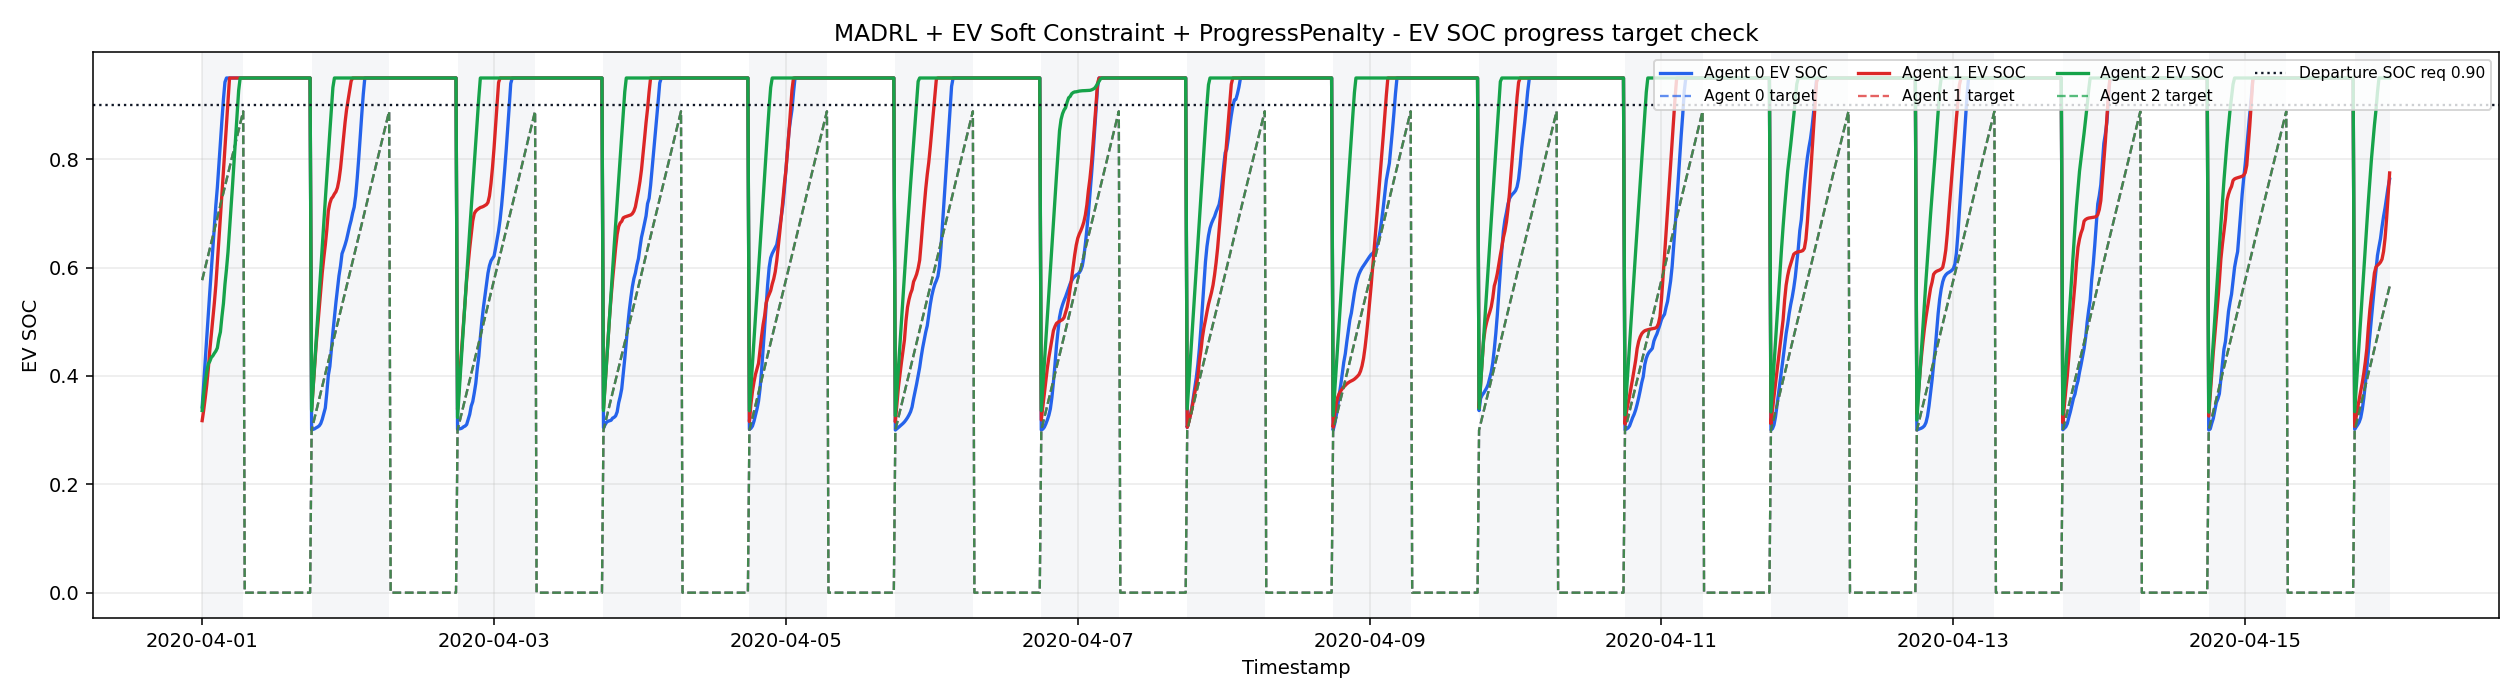

15. Training reward - EV soft constraint progress penalty


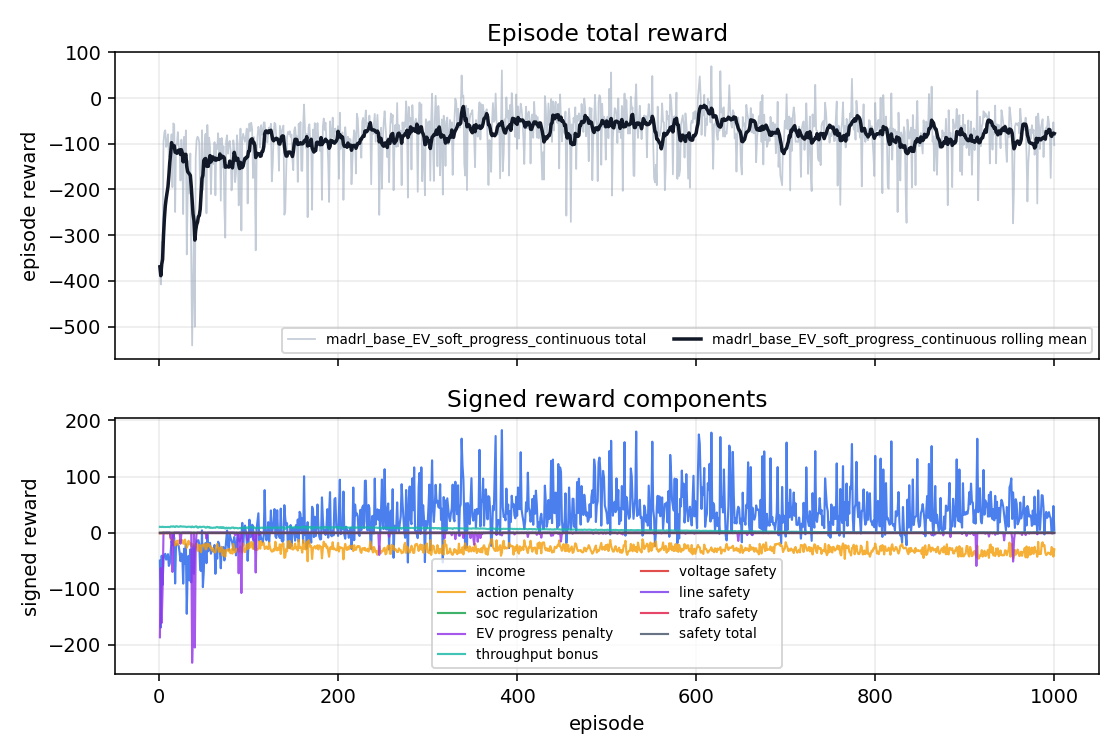

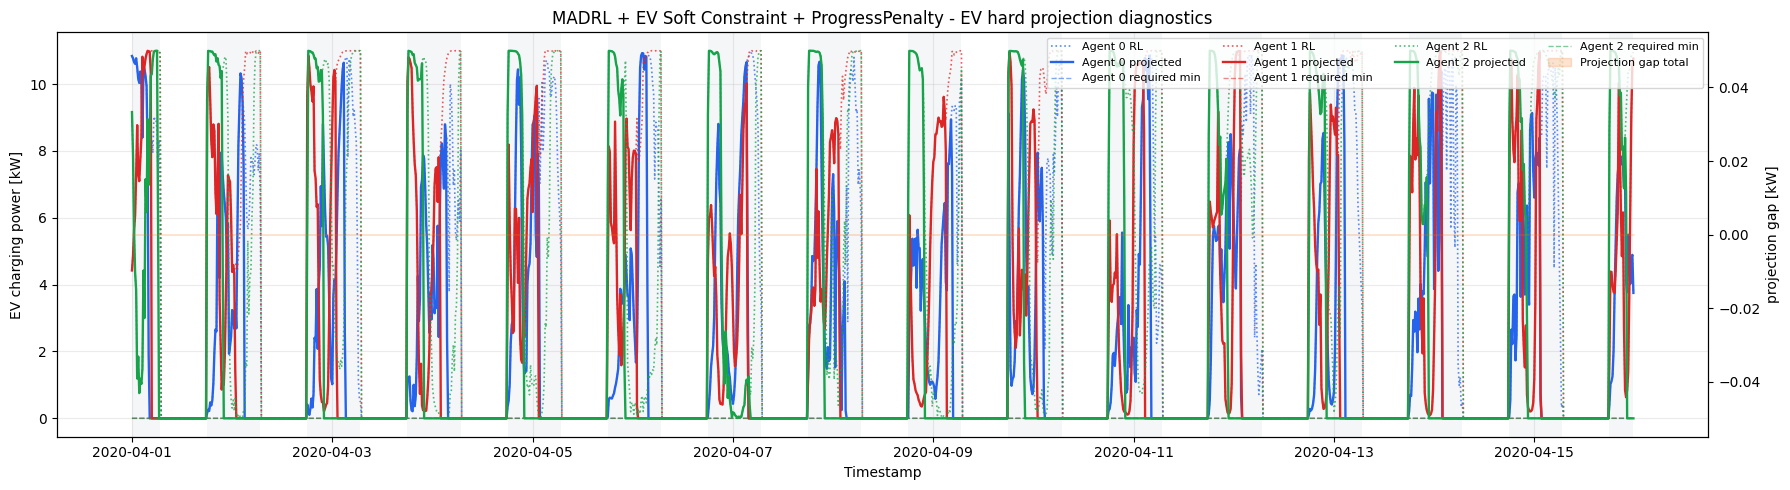

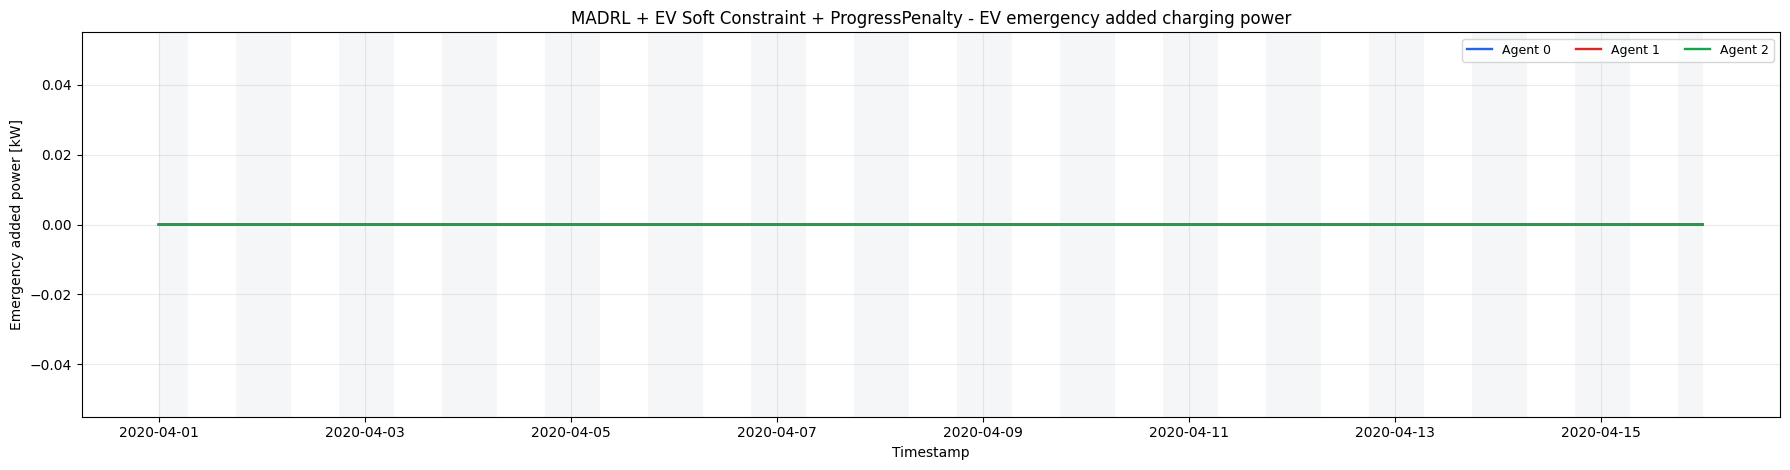

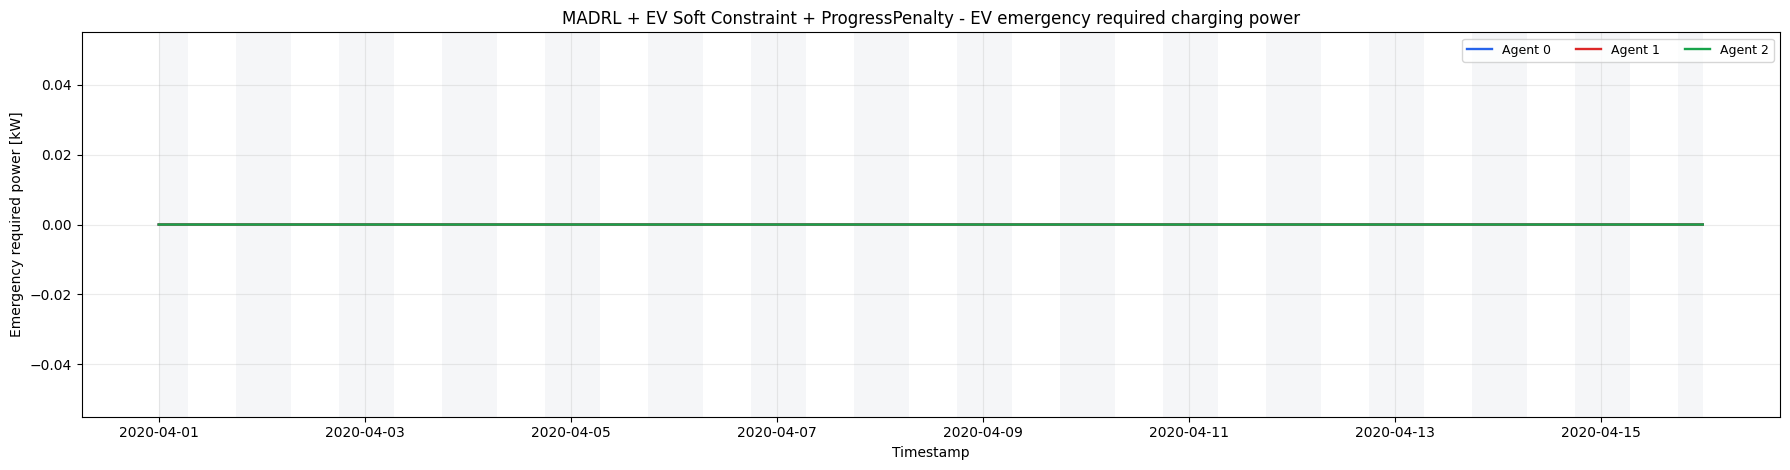

In [4]:
plt.close("all")
# Generate unique source figures first, then create _progress display copies without touching existing madrl_base_*.png files.
figures = plot_madrl_outputs(result, run_dir)
figure_suffix = "progress"
fig_dir = run_dir / "figures"
renamed_figures = {}
source_prefix = scheme_name
display_prefix = base_scheme_name
for name, fig in list(figures.items()):
    if name.startswith(f"{source_prefix}_"):
        bare_name = name.removeprefix(f"{source_prefix}_")
        suffixed_name = f"{display_prefix}_{bare_name}_{figure_suffix}"
        src_path = fig_dir / f"{name}.png"
        dst_path = fig_dir / f"{suffixed_name}.png"
        if src_path.exists():
            shutil.copy2(src_path, dst_path)
        renamed_figures[suffixed_name] = fig
figures.update(renamed_figures)

_plot_specs = [
    ("1. Power balance", "madrl_base_power_balance_progress"),
    ("2. Price", "madrl_base_price_progress"),
    ("3. Battery power vs price", "madrl_base_battery_power_price_progress"),
    ("4. EV charging power vs price", "madrl_base_ev_charge_price_progress"),
    ("5. Total cumulative cost", "madrl_base_total_cost_progress"),
    ("6. Cost components per step", "madrl_base_cost_components_progress"),
    ("7. Cumulative cost components", "madrl_base_cumulative_cost_components_progress"),
    ("8. Battery power and SoC", "madrl_base_battery_soc_progress"),
    ("9. Voltage", "madrl_base_voltage_progress"),
    ("10. Net load", "madrl_base_net_load_progress"),
    ("11. EV SOC", "madrl_base_ev_soc_progress"),
    ("12. EV charging power", "madrl_base_ev_charge_kw_progress"),
    ("13. EV departure SOC requirement check", "madrl_base_ev_departure_check_progress"),
    ("14. EV SOC progress target check", "madrl_base_ev_progress_check_progress"),
    ("15. Training reward", "madrl_base_learning_curve_progress"),
]
for title, name in _plot_specs:
    path = fig_dir / f"{name}.png"
    if path.exists():
        print(f"{title} - EV soft constraint progress penalty")
        display(Image(filename=str(path)))
        if name in figures:
            plt.close(figures[name])
    else:
        print(f"[missing] {title}: {path}")
